In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!find "/content/drive/MyDrive" -iname "*SHREC2017*"

/content/drive/MyDrive/KUBIG/contest/HandGestureDataset_SHREC2017.tar.gz


In [3]:
!mkdir -p /content/shrec2017
!tar -xvzf "/content/drive/MyDrive/KUBIG/contest/HandGestureDataset_SHREC2017.tar.gz" -C /content/shrec2017

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
HandGestureDataset_SHREC2017/gesture_13/finger_1/subject_6/essai_4/60_depth.png
HandGestureDataset_SHREC2017/gesture_12/finger_2/subject_14/essai_1/97_depth.png
HandGestureDataset_SHREC2017/gesture_6/finger_2/subject_4/essai_1/35_depth.png
HandGestureDataset_SHREC2017/gesture_8/finger_1/subject_13/essai_2/12_depth.png
HandGestureDataset_SHREC2017/gesture_10/finger_1/subject_1/essai_2/30_depth.png
HandGestureDataset_SHREC2017/gesture_10/finger_1/subject_1/essai_1/37_depth.png
HandGestureDataset_SHREC2017/gesture_14/finger_2/subject_24/essai_3/11_depth.png
HandGestureDataset_SHREC2017/gesture_12/finger_2/subject_2/essai_1/128_depth.png
HandGestureDataset_SHREC2017/gesture_14/finger_2/subject_17/essai_1/23_depth.png
HandGestureDataset_SHREC2017/gesture_11/finger_2/subject_7/essai_2/105_depth.png
HandGestureDataset_SHREC2017/gesture_6/finger_2/subject_17/essai_1/6_depth.png
HandGestureDataset_SHREC2017/gesture_10/finger_2/subject_28/essai_3/2_depth.png
H

In [ ]:
!du -sh /content/shrec2017
!ls /content/shrec2017/HandGestureDataset_SHREC2017 | head

22G	/content/shrec2017
display_gesture.m
display_sequence.py
gesture_1
gesture_10
gesture_11
gesture_12
gesture_13
gesture_14
gesture_2
gesture_3


In [4]:
# 관절 순서 확인

with open("/content/shrec2017/HandGestureDataset_SHREC2017/display_sequence.py") as f:
    print(f.read())

import numpy as np
from scipy import misc
import os
import matplotlib.pyplot as plt

##### To modify

root_datase = '/media/qdesmedt/HD_DESMEDT/to_remove/'

idx_gesture = 1
idx_subject = 1
idx_finger = 1
idx_essai = 1

####

# Idx of the bones in the hand skeleton to display it.

bones = np.array([
	[0, 1],
    [0, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [1, 6],
    [6, 7],
    [7, 8],
    [8, 9],
    [1, 10],
    [10, 11],
    [11, 12],
    [12, 13],
    [1, 14],
    [14, 15],
    [15, 16],
    [16, 17],
    [1, 18],
    [18, 19],
    [19, 20],
    [20, 21]
    ]
);

#Path of the gesture


path_gesture = root_datase + '/gesture_' + str(idx_gesture) + '/finger_' \
			+ str(idx_finger) + '/subject_' + str(idx_subject) + '/essai_' + str(idx_essai)+'/'



if os.path.isdir(path_gesture):

	path_skeletons_image = path_gesture+ '/skeletons_image.txt'

	skeletons_image = np.loadtxt(path_skeletons_image)

	pngDepthFiles = np.zeros([skeletons_image.shape[0], 480, 640])
	skeletons_display = 

In [5]:
import numpy as np

sample_path = "/content/shrec2017/HandGestureDataset_SHREC2017/gesture_4/finger_1/subject_11/essai_2/skeletons_world.txt"
data = np.loadtxt(sample_path)
print(data.shape)
data = data.reshape(-1, 22, 3)
print(data.shape)

(19, 66)
(19, 22, 3)


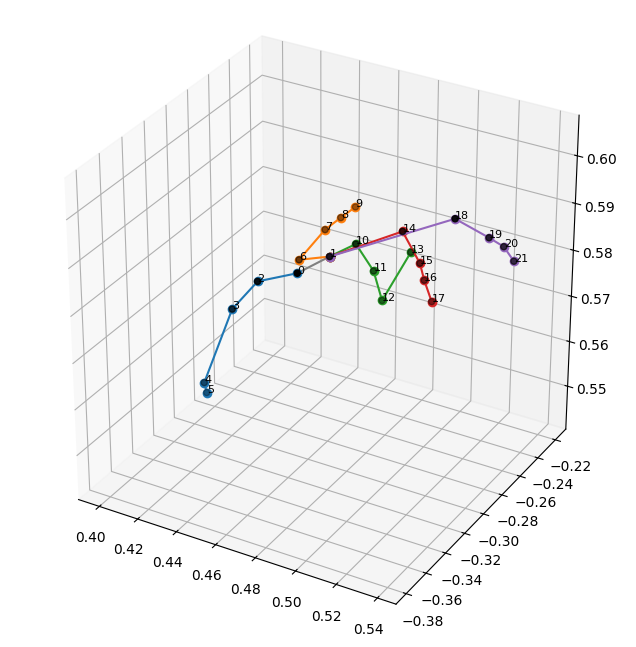

In [6]:
import matplotlib.pyplot as plt

frame0 = data[0]
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

fingers = {
    "thumb":  [0, 2, 3, 4, 5],   # 손목(0)에서 시작 (공식 구조로 수정됨)
    "index":  [1, 6, 7, 8, 9],
    "middle": [1, 10, 11, 12, 13],
    "ring":   [1, 14, 15, 16, 17],
    "pinky":  [1, 18, 19, 20, 21],
}

ax.scatter(frame0[:,0], frame0[:,1], frame0[:,2], color='black')
for i, (x,y,z) in enumerate(frame0):
    ax.text(x, y, z, str(i), fontsize=8)

ax.plot(*zip(frame0[0], frame0[1]), color='gray')  # 손목-손바닥 연결

for finger, idxs in fingers.items():
    pts = frame0[idxs]
    ax.plot(pts[:,0], pts[:,1], pts[:,2], marker='o')

ax.set_box_aspect([1,1,1])
plt.show()

In [7]:
import pandas as pd
import glob

root = "/content/shrec2017/HandGestureDataset_SHREC2017"
records = []
for skel_path in glob.glob(f"{root}/gesture_*/finger_*/subject_*/essai_*/skeletons_world.txt"):
    parts = skel_path.split("/")
    gesture = int(parts[-5].replace("gesture_", ""))      # 어떤 동작인지 (동작 1~14번)
    finger  = int(parts[-4].replace("finger_", ""))       # 손가락 하나(1), 손 전체(2)
    subject = int(parts[-3].replace("subject_", ""))      # 누가 했는지 (참가자 1~28번)
    essai   = int(parts[-2].replace("essai_", ""))        # 몇 번째로 반복했는지
    n_frames = np.loadtxt(skel_path).shape[0]             # 몇 프레임(시간 단위)에 걸쳐 촬영됐는지(=얼마나 오래 걸렸는지)
    records.append({"gesture": gesture, "finger": finger, "subject": subject, "essai": essai, "n_frames": n_frames, "path": skel_path})

df = pd.DataFrame(records)
print(len(df))
df.head()

2800


,gesture,finger,subject,essai,n_frames,path
0,14,1,25,3,63,/content/shrec2017/HandGestureDataset_SHREC201...
1,14,1,25,2,60,/content/shrec2017/HandGestureDataset_SHREC201...
2,14,1,25,4,51,/content/shrec2017/HandGestureDataset_SHREC201...
3,14,1,25,5,63,/content/shrec2017/HandGestureDataset_SHREC201...
4,14,1,25,1,80,/content/shrec2017/HandGestureDataset_SHREC201...


In [8]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [9]:
print(df["n_frames"].describe())

count    2800.00000
mean       58.91750
std        26.86128
min         7.00000
25%        37.00000
50%        57.00000
75%        76.00000
max       171.00000
Name: n_frames, dtype: float64


[데이터 탐색] SHREC'17 실제 시퀀스 길이 분포 확인\
공식 문서는 시퀀스 길이를 20-50프레임이라 명시하지만, 2800개 전체를 직접 측정한 결과 평균 58.9프레임, 중앙값 57프레임으로 절반 이상이 공식 스펙을 초과함(50프레임 초과 1669개, 59.6%). 최소 7프레임~최대 171프레임까지 편차가 큼. 다만 계획된 가림 길이 L=5/10/20/30 실험 설계는 이 실제 분포 기준으로도 적절한 범위이며, 짧은 시퀀스(N+L 미만)는 가림 샘플 생성 시 자동 제외 처리함.

##1. 가림 샘플 만들기

In [10]:
# 전처리 + 가림 생성

def load_and_preprocess(path):
    """스켈레톤 파일 하나를 읽어서 전처리까지 끝낸 배열 반환"""
    seq = np.loadtxt(path).reshape(-1, 22, 3)
    seq = seq - seq[:, 0:1, :]  # 손목(0) 기준 상대좌표
    scale = np.linalg.norm(seq[:, 1, :], axis=1).mean()  # 손목-손바닥 거리로 정규화
    seq = seq / (scale + 1e-8)
    return seq

def make_occlusion_sample(seq, N, L, seed=None):
    """전처리된 시퀀스 하나에서 (입력, 정답) 쌍 하나 생성"""
    rng = np.random.default_rng(seed)
    T = seq.shape[0]
    if T < N + L:
        return None
    start = rng.integers(N, T - L + 1)
    input_seq  = seq[start-N:start]
    target_seq = seq[start:start+L]
    return input_seq, target_seq

In [11]:
# 전체 데이터셋에 걸쳐 대량 생성

N = 15  # 입력으로 쓸 프레임 수
L_list = [5, 10, 20, 30]  # 실험할 가림 길이들

dataset = []  # (입력, 정답, 메타정보)

for _, row in df.iterrows():
    seq = load_and_preprocess(row["path"])

    for L in L_list:
        result = make_occlusion_sample(seq, N=N, L=L, seed=None)
        if result is None:      # 시퀀스가 너무 짧은 경우
            continue
        input_seq, target_seq = result
        dataset.append({
            "gesture": row["gesture"],
            "subject": row["subject"],
            "L": L,
            "input": input_seq,
            "target": target_seq
        })

print("총 생성된 샘플 개수:", len(dataset))       # 짧은 시퀀스들이 걸러지고 난 샘플 개수

총 생성된 샘플 개수: 9327


In [12]:
# 데이터 확인

import pandas as pd

meta_df = pd.DataFrame([{"gesture": d["gesture"], "subject": d["subject"], "L": d["L"]} for d in dataset])
print(meta_df["L"].value_counts())  # L값별로 몇 개씩 만들어졌는지

L
5     2718
10    2578
20    2187
30    1844
Name: count, dtype: int64


In [13]:
import pickle

with open("/content/drive/MyDrive/KUBIG/contest/occlusion_dataset.pkl", "wb") as f:
    pickle.dump(dataset, f)

print("저장 완료")

저장 완료


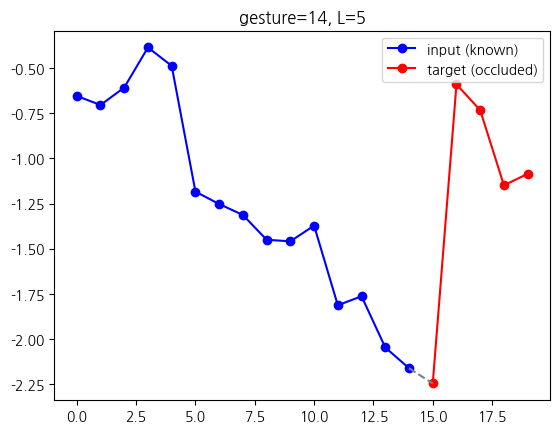

In [15]:
# 샘플 하나 시각화

sample = dataset[0]
input_seq, target_seq = sample["input"], sample["target"]

fig, ax = plt.subplots()
joint = 9  # 검지 끝

input_x = input_seq[:, joint, 0]
target_x = target_seq[:, joint, 0]

ax.plot(range(len(input_x)), input_x, 'o-', color='blue', label='input (known)')
ax.plot(range(len(input_x), len(input_x)+len(target_x)), target_x, 'o-', color='red', label='target (occluded)')

ax.plot([len(input_x)-1, len(input_x)], [input_x[-1], target_x[0]], '--', color='gray')

ax.legend()
ax.set_title(f"gesture={sample['gesture']}, L={sample['L']}")
plt.show()

##2. 제스처별/참가자별 통계

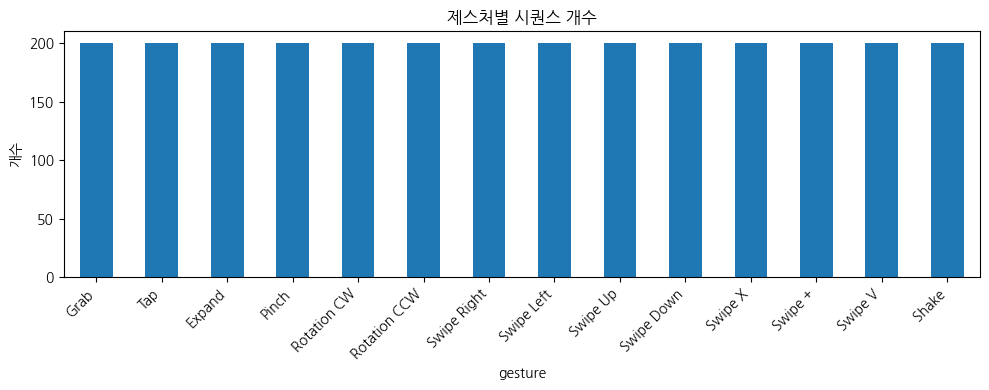

gesture
Grab            200
Tap             200
Expand          200
Pinch           200
Rotation CW     200
Rotation CCW    200
Swipe Right     200
Swipe Left      200
Swipe Up        200
Swipe Down      200
Swipe X         200
Swipe +         200
Swipe V         200
Shake           200
Name: count, dtype: int64


In [16]:
# 제스처별 개수 확인

gesture_names = {
    1: "Grab", 2: "Tap", 3: "Expand", 4: "Pinch",
    5: "Rotation CW", 6: "Rotation CCW", 7: "Swipe Right", 8: "Swipe Left",
    9: "Swipe Up", 10: "Swipe Down", 11: "Swipe X", 12: "Swipe +",
    13: "Swipe V", 14: "Shake"
}

gesture_counts = df["gesture"].value_counts().sort_index()
gesture_counts.index = gesture_counts.index.map(gesture_names)

fig, ax = plt.subplots(figsize=(10,4))
gesture_counts.plot(kind="bar", ax=ax)
ax.set_title("제스처별 시퀀스 개수")
ax.set_ylabel("개수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(gesture_counts)

In [17]:
# 손가락 구성 분포

finger_counts = df["finger"].value_counts().sort_index()
print(finger_counts)

finger
1    1400
2    1400
Name: count, dtype: int64


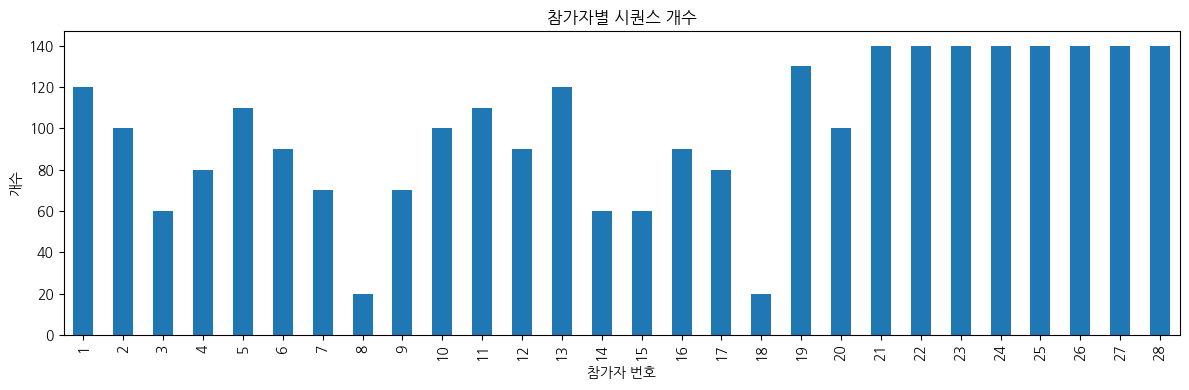

참가자별 최소/최대 개수: 20 / 140


In [ ]:
# 참가자별 개수 확인

subject_counts = df["subject"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12,4))
subject_counts.plot(kind="bar", ax=ax)
ax.set_title("참가자별 시퀀스 개수")
ax.set_xlabel("참가자 번호")
ax.set_ylabel("개수")
plt.tight_layout()
plt.show()

print("참가자별 최소/최대 개수:", subject_counts.min(), "/", subject_counts.max())

In [ ]:
# 제스처 x 손가락 교차표

cross = pd.crosstab(df["gesture"], df["finger"])
cross.index = cross.index.map(gesture_names)
cross.columns = ["finger=1(한 손가락)", "finger=2(손 전체)"]
print(cross)

              finger=1(한 손가락)  finger=2(손 전체)
gesture                                      
Grab                      100             100
Tap                       100             100
Expand                    100             100
Pinch                     100             100
Rotation CW               100             100
Rotation CCW              100             100
Swipe Right               100             100
Swipe Left                100             100
Swipe Up                  100             100
Swipe Down                100             100
Swipe X                   100             100
Swipe +                   100             100
Swipe V                   100             100
Shake                     100             100


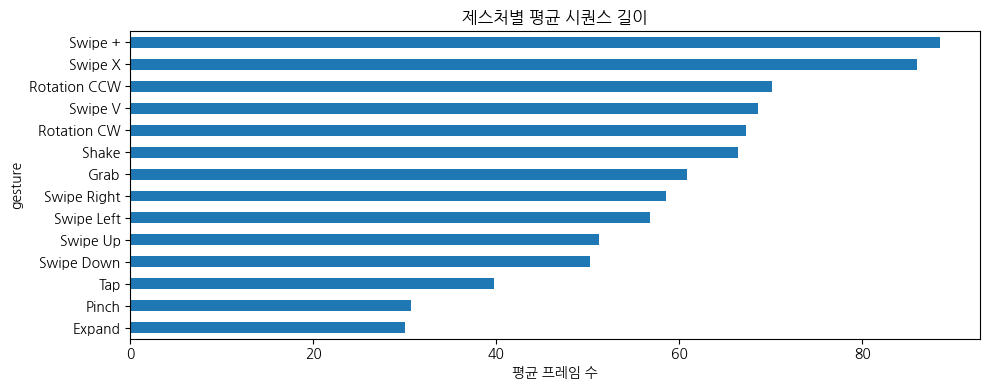

In [ ]:
# 제스처별 평균 길이 비교

length_by_gesture = df.groupby("gesture")["n_frames"].mean()
length_by_gesture.index = length_by_gesture.index.map(gesture_names)
length_by_gesture = length_by_gesture.sort_values()

fig, ax = plt.subplots(figsize=(10,4))
length_by_gesture.plot(kind="barh", ax=ax)
ax.set_title("제스처별 평균 시퀀스 길이")
ax.set_xlabel("평균 프레임 수")
plt.tight_layout()
plt.show()

제스처/참가자별 분포 확인

- 제스처(14종) 및 손가락 구성(1개/전체) 모두 완벽하게 균형 잡힘 (모든 제스처×손가락 조합이 정확히 100개씩 총 2800개, 불균형 없음).
- 참가자별 시퀀스 개수는 불균형함(최소 20개에서 최대 140개, 최대 7배 차이). \
essai(반복 횟수)가 사람마다 1~10회로 편차가 컸던 것이 원인. → 추후 leave-one-subject-out 검증 시, 참가자별 평가 데이터 양 차이를 감안해서 결과를 해석해야 함.
- 제스처별 평균 길이 차이가 뚜렷함: Swipe +(88프레임)·Swipe X(85프레임)가 가장 길고, Expand·Pinch(30프레임)·Tap(40프레임)이 가장 짧음(동작 복잡도 차이로 추정). → 동일한 가림 길이 L을 적용해도 제스처에 따라 체감 난이도가 다를 수 있음(짧은 제스처일수록 같은 L이 상대적으로 더 큰 비중을 차지).